## Анализ результатов вычисления базисов Грёбнера

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
plt.style.use('seaborn-v0_8')
sns.set_palette("tab10")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

Путь к файлу с результатами:

In [3]:
CSV_PATH = 'summary_table_timeout_3600.csv'

Загрузка и предобработка данных:

In [7]:
df = pd.read_csv(
    CSV_PATH,
    sep=';',                  # разделитель столбцов
    decimal=',',              # десятичный разделитель
    quotechar='"',            # кавычки вокруг строк
    skipinitialspace=True,    # убирает пробелы после запятых
    encoding='utf-8',
    low_memory=False
)

# Принудительно приводим числовые столбцы к float
numeric_cols = ['time', 'dimension', 'num_vars', 'basis_size', 'avr_memory', 'max_memory', 'mem_per_sec', 'crit1', 'crit2']

for col in numeric_cols:
    if col in df.columns:
        # Убираем лишние символы и заменяем пустые строки на NaN
        df[col] = df[col].astype(str).str.strip().str.replace('"', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# В режиме clean обнуляем метрики памяти
if 'mode' in df.columns:
    clean_mask = df['mode'] == 'clean'
    for col in ['avr_memory', 'max_memory', 'mem_per_sec']:
        if col in df.columns:
            df.loc[clean_mask, col] = np.nan
            
df['log_time'] = np.log10(df['time'].clip(lower=0.001))
df['completed'] = df['status'] == 'ok'
df['timed_out'] = df['status'] == 'timeout'
df['has_error'] = df['status'] == 'error'

In [8]:
df.head(10)

,test,method,order,time,dimension,num_vars,basis_size,avr_memory,max_memory,mem_per_sec,crit1,crit2,mode,status,log_time,completed,timed_out,has_error
0,assur44,ginv,deglex,1101.779,8,8,87.0,NaN,NaN,NaN,1919.0,3352.0,clean,ok,3.042094,True,False,False
1,assur44,sympy,deglex,3600.032,8,8,NaN,NaN,NaN,NaN,NaN,NaN,clean,timeout,3.556306,False,True,False
2,benchmark_D1,ginv,deglex,87.680,12,12,86.0,NaN,NaN,NaN,2479.0,2185.0,clean,ok,1.942901,True,False,False
3,benchmark_D1,sympy,deglex,3600.042,12,12,NaN,NaN,NaN,NaN,NaN,NaN,clean,timeout,3.556308,False,True,False
4,benchmark_i1,ginv,deglex,1120.729,10,10,118.0,NaN,NaN,NaN,3559.0,3487.0,clean,ok,3.049501,True,False,False
5,benchmark_i1,sympy,deglex,3600.036,10,10,NaN,NaN,NaN,NaN,NaN,NaN,clean,timeout,3.556307,False,True,False
6,boon,ginv,deglex,0.143,6,6,12.0,NaN,NaN,NaN,108.0,32.0,clean,ok,-0.844664,True,False,False
7,boon,sympy,deglex,0.035,6,6,11.0,NaN,NaN,NaN,NaN,NaN,clean,ok,-1.455932,True,False,False
8,butcher8,ginv,deglex,44.038,8,8,54.0,NaN,NaN,NaN,568.0,1292.0,clean,ok,1.643828,True,False,False
9,butcher8,sympy,deglex,29.880,8,8,54.0,NaN,NaN,NaN,NaN,NaN,clean,ok,1.475381,True,False,False


### Таблица завершенности тестов

In [6]:
pd.crosstab(df['method'], df['status'], margins=True)

status,ok,timeout,All
method,,,
ginv,91,9,100
sympy,74,26,100
All,165,35,200


### Сравнение статистических характеристик времени

#### Первоначальный расчет по всем данным

Найдем статистические характеристики времени вычисления по всему датасету (в т.ч. по тестам с таймаутом)

In [12]:
print("="*60)
print("Статистические характеристики времени (с учётом таймаутов)")
print("="*60)

stats = df.groupby('method')['time'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(3)
stats

Статистические характеристики времени (с учётом таймаутов)


,count,mean,median,std,min,max
method,,,,,,
ginv,100,570.132,21.890,1099.905,0.001,3600.095
sympy,100,1069.523,24.672,1565.542,0.002,3600.100


In [13]:
# Кто в среднем быстрее
mean_sympy = stats.loc['sympy', 'mean']
mean_ginv = stats.loc['ginv', 'mean']
print(f"\nВ среднем быстрее: {'SymPy' if mean_sympy < mean_ginv else 'GInv'} "
      f"({min(mean_sympy, mean_ginv):.2f} сек < {max(mean_sympy, mean_ginv):.2f} сек)")


В среднем быстрее: GInv (570.13 сек < 1069.52 сек)


#### Расчет только по завершенным обоими методами тестам

Для расчета статистических метрик корректно использовать только те тесты, где решение найдено обоими методами, при этом не учитывая таймаут. Если решение не достигнуто, некорректно использовать его в анализе результатов.

In [17]:
print("="*80)
print("Статистические характеристики времени (только по успешно решенным каждым методом)")
print("="*80)

# Доля успешно решённых
success = df.groupby('method')['completed'].agg(['sum', 'count'])
success['success_%'] = (success['sum'] / success['count'] * 100).round(1)
print("Доля успешно решённых задач:")
success[['success_%']]

Статистические характеристики времени (только по успешно решенным каждым методом)
Доля успешно решённых задач:


,success_%
method,
ginv,91.0
sympy,74.0


In [18]:
# Пересечение
pivot = df.pivot(index='test', columns='method', values=['time', 'completed'])
both_ok = pivot[(pivot[('completed', 'ginv')] == True) & 
                (pivot[('completed', 'sympy')] == True)].index

common_df = df[df['test'].isin(both_ok)].copy()

print(f"\nОбщих успешно решённых задач: {len(both_ok)} из 100\n")

# Статистика только по общим задачам
stats_common = common_df.groupby('method')['time'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max',
    lambda x: np.exp(np.mean(np.log(x)))   # geometric mean
]).round(3)

stats_common.columns = ['count', 'mean', 'median', 'std', 'min', 'max', 'geometric_mean']
print("Статистика времени только по общим решённым задачам:")
stats_common


Общих успешно решённых задач: 71 из 100

Статистика времени только по общим решённым задачам:


,count,mean,median,std,min,max,geometric_mean
method,,,,,,,
ginv,71,119.440,1.663,392.680,0.001,2521.447,2.366
sympy,71,104.713,0.848,311.693,0.002,1812.610,1.782


In [19]:
# Win-rate (кто чаще быстрее)
times_g = common_df[common_df['method'] == 'ginv']['time'].reset_index(drop=True)
times_s = common_df[common_df['method'] == 'sympy']['time'].reset_index(drop=True)

win_ginv = (times_g < times_s).sum()
win_sympy = len(both_ok) - win_ginv

print(f"\nWin-rate на {len(both_ok)} общих задачах:")
print(f"  GInv быстрее в {win_ginv} случаях ({win_ginv/len(both_ok)*100:.1f}%)")
print(f"  SymPy быстрее в {win_sympy} случаях ({win_sympy/len(both_ok)*100:.1f}%)")


Win-rate на 71 общих задачах:
  GInv быстрее в 17 случаях (23.9%)
  SymPy быстрее в 54 случаях (76.1%)


Для корректного сравнения времени вычисления базиса Грёбнера статистики рассчитывались только на 71 задаче, успешно решённой обоими методами. На этом подмножестве среднее время работы SymPy составило 104,7 с, а GInv — 119,4 с. Однако GInv успешно завершил 91 задачу из 100 (91 %), в то время как SymPy — только 74 (74 %). Это показывает, что инволютивное деление Janet (GInv) значительно надёжнее на тяжёлых примерах, хотя на лёгких и средних задачах классическое деление SymPy часто оказывается быстрее.

### Сравнение по тестам

In [20]:
pivot = df.pivot_table(index='test', columns='method', values=['time', 'status'], aggfunc='first')

# Упрощаем
pivot_time = pivot['time'].copy()
pivot_time['winner'] = pivot_time.apply(
    lambda row: 'SymPy' if row['sympy'] < row.get('ginv', np.inf) else
                'GInv' if row['ginv'] < row.get('sympy', np.inf) else
                'Оба таймаут' if pd.isna(row['sympy']) and pd.isna(row['ginv']) else 'Ничья', axis=1)

print("Количество наиболее быстрых расчетов по тестам")
pivot_time['winner'].value_counts()

Количество наиболее быстрых расчетов по тестам


winner
SymPy    62
GInv     37
Ничья     1
Name: count, dtype: int64

#### Сравнительный анализ GInv и SymPy

In [23]:
print("="*40)
print("Tесты, где GInv значительно быстрее:")
print("="*40)
print(pivot_time[pivot_time['winner'] == 'GInv'].sort_values('ginv').head(15))

print("="*40)
print("Тесты, где SymPy значительно быстрее:")
print("="*40)
print(pivot_time[pivot_time['winner'] == 'SymPy'].sort_values('sympy').head(15))

Tесты, где GInv значительно быстрее:
method        ginv     sympy winner
test                               
mickey       0.001     0.002   GInv
sparse5      0.003     0.005   GInv
lanconelli   0.009     0.054   GInv
hunecke      0.011    19.397   GInv
liu          0.074    17.534   GInv
reif         0.300     1.844   GInv
lichtblau    1.798  1607.307   GInv
chemequs     2.141    10.675   GInv
tangents     3.388    17.364   GInv
cassou       3.671  3600.031   GInv
rabmo       15.113   329.069   GInv
matrix      19.354    26.471   GInv
redcyc6     24.425  3600.026   GInv
hcyclic6    26.570   225.783   GInv
speer       83.085   143.714   GInv
Тесты, где SymPy значительно быстрее:
method        ginv  sympy winner
test                            
solotarev    0.017  0.007  SymPy
test         0.015  0.007  SymPy
chandra4     0.049  0.010  SymPy
hemmecke     0.090  0.015  SymPy
lorentz      0.054  0.016  SymPy
conform1     0.057  0.019  SymPy
quadgrid     0.055  0.020  SymPy
boon         0.1

## Таймаут по тестам

Тесты, где один завершился, а другой нет

In [24]:
diff_status = df.pivot_table(index='test', columns='method', values='status', aggfunc='first')
print(diff_status[diff_status.nunique(axis=1) > 1])

method           ginv    sympy
test                          
assur44            ok  timeout
benchmark_D1       ok  timeout
benchmark_i1       ok  timeout
cassou             ok  timeout
chemkin            ok  timeout
cohn3              ok  timeout
d1                 ok  timeout
eco10         timeout       ok
el44               ok  timeout
fabrice24          ok  timeout
filter9            ok  timeout
hairer2       timeout       ok
hietarinta1        ok  timeout
i1                 ok  timeout
jcf26              ok  timeout
katsura8           ok  timeout
kin1               ok  timeout
kotsireas          ok  timeout
noon7         timeout       ok
pinchon1           ok  timeout
rbpl               ok  timeout
rbpl24             ok  timeout
redcyc6            ok  timeout


## Визуализация

### Статистическое сравнение производительности двух библиотек с учётом разных подходов к обработке таймаутов

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6944\1733125042.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=success.index, y=success['success_%'], palette=palette, ax=axes[0])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_6944\1733125042.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([labels.get(x.get_text(), x.get_text()) for x in ax.get_xticklabels()], fontsize=11)


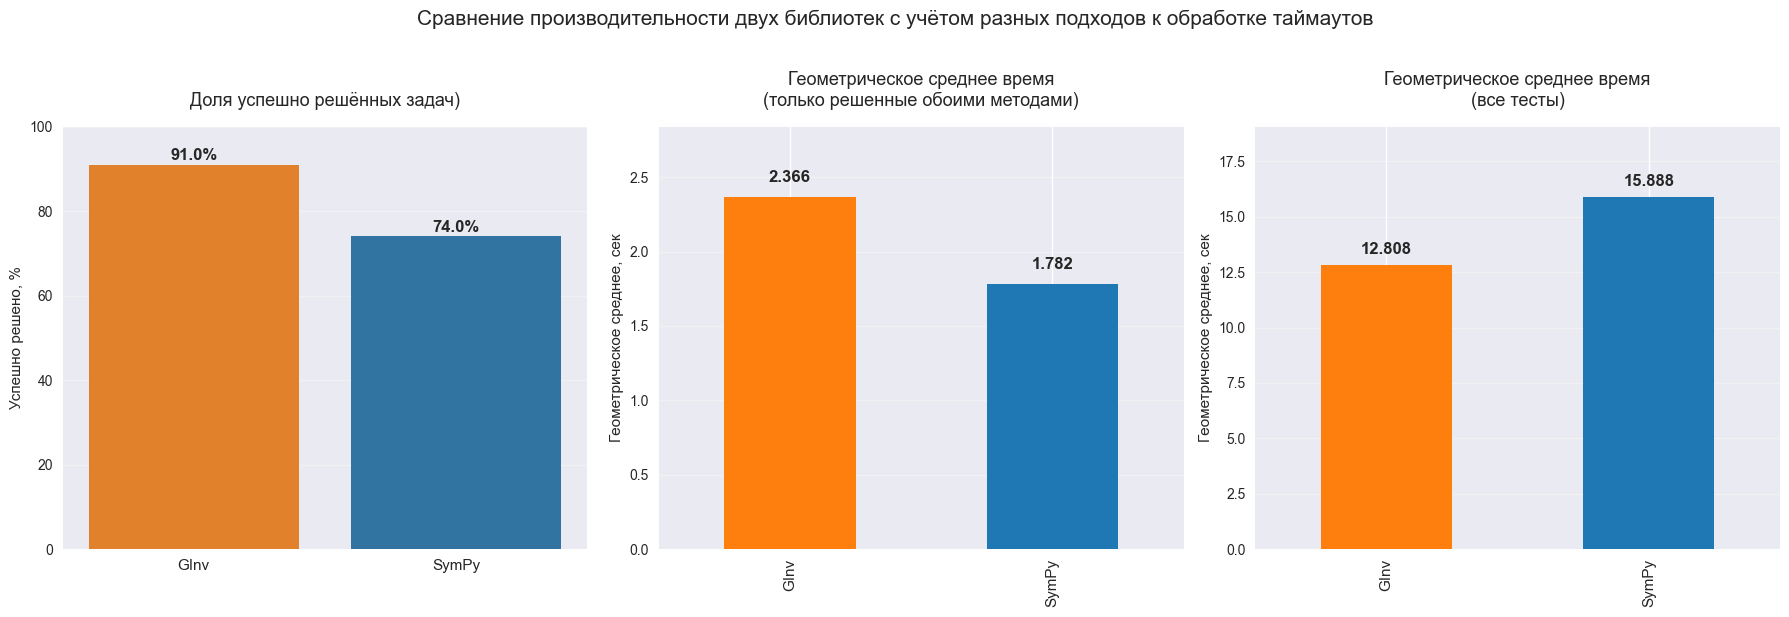

In [32]:
success = df.groupby('method')['completed'].agg(['sum', 'count'])
success['success_%'] = (success['sum'] / success['count'] * 100).round(1)

# Общие задачи
pivot = df.pivot(index='test', columns='method', values=['time', 'completed'])
both_ok_mask = (pivot[('completed', 'ginv')] == True) & (pivot[('completed', 'sympy')] == True)
common_df = df[df['test'].isin(pivot[both_ok_mask].index)]

geo_common = common_df.groupby('method')['time'].apply(lambda x: np.exp(np.mean(np.log(x)))).round(3)

# Все 100 задач (censored)
df['time_censored'] = df['time'].clip(upper=3600)
geo_all = df.groupby('method')['time_censored'].apply(
    lambda x: np.exp(np.mean(np.log(x)))
).round(3)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

palette = {'ginv': '#ff7f0e', 'sympy': '#1f77b4'}
labels = {'ginv': 'GInv', 
          'sympy': 'SymPy'}

# Доля решённых задач
sns.barplot(x=success.index, y=success['success_%'], palette=palette, ax=axes[0])
axes[0].set_title('Доля успешно решённых задач)', fontsize=13, pad=15)
axes[0].set_ylabel('Успешно решено, %')
axes[0].set_ylim(0, 100)
for i, v in enumerate(success['success_%']):
    axes[0].text(i, v + 1, f'{v}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')

# Geometric mean на общих задачах
geo_common.plot(kind='bar', color=[palette['ginv'], palette['sympy']], ax=axes[1])
axes[1].set_title('Геометрическое среднее время\n(только решенные обоими методами)', fontsize=13, pad=15)
axes[1].set_ylabel('Геометрическое среднее, сек')
axes[1].set_ylim(0, max(geo_common)*1.2)
for i, v in enumerate(geo_common):
    axes[1].text(i, v + 0.1, f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')

# 3 Geometric mean на всех тестах (с таймаутом)
geo_all.plot(kind='bar', color=[palette['ginv'], palette['sympy']], ax=axes[2])
axes[2].set_title('Геометрическое среднее время\n(все тесты)', fontsize=13, pad=15)
axes[2].set_ylabel('Геометрическое среднее, сек')
axes[2].set_ylim(0, max(geo_all)*1.2)
for i, v in enumerate(geo_all):
    axes[2].text(i, v + 0.5, f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
axes[2].set_xlabel('')

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels([labels.get(x.get_text(), x.get_text()) for x in ax.get_xticklabels()], fontsize=11)

plt.suptitle('Сравнение производительности двух библиотек с учётом разных подходов к обработке таймаутов', 
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

Левая гистограмма демонстрирует значительно более высокую надёжность инволютивного Janet-подобного деления (GInv). Средняя гистограмма показывает, что на 71 задаче, успешно решённой обоими методами, классическое деление (SymPy) немного быстрее. Правая гистограмма (censored statistics) отражает реальную картину: при учёте всех 100 систем GInv даёт меньшее геометрическое среднее время благодаря способности решать сложные системы до истечения лимита в 3600 с. Из этого следует, что тип полиномиального деления существенно влияет на поведение алгоритма при росте размерности и числа переменных.

### Censored Scatterplot по всем тестам

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6944\2914008991.py:27: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


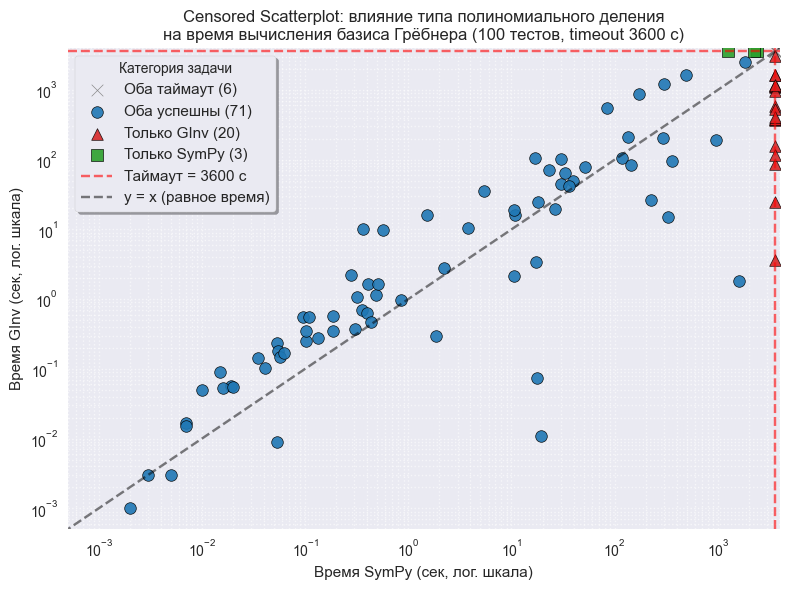

In [30]:
pivot = df.pivot(index='test', columns='method', values=['time', 'completed', 'num_vars', 'dimension'])

both_ok = (pivot[('completed', 'ginv')] == True) & (pivot[('completed', 'sympy')] == True)
only_ginv = (pivot[('completed', 'ginv')] == True) & (pivot[('completed', 'sympy')] == False)
only_sympy = (pivot[('completed', 'ginv')] == False) & (pivot[('completed', 'sympy')] == True)
both_timeout = ~(both_ok | only_ginv | only_sympy)

# Создаём датафрейм для графика
plot_df = pd.DataFrame({
    'test': pivot.index,
    'time_sympy': pivot[('time', 'sympy')],
    'time_ginv': pivot[('time', 'ginv')],
    'num_vars': pivot[('num_vars', 'ginv')],
    'category': np.select(
        [both_ok, only_ginv, only_sympy, both_timeout],
        ['Оба успешны', 'Только GInv', 'Только SymPy', 'Оба таймаут'],
        default='error'
    )
})

fig, ax = plt.subplots(figsize=(8, 6))

colors = {'Оба успешны': '#1f77b4', 'Только GInv': '#d62728', 'Только SymPy': '#2ca02c', 'Оба таймаут': '#7f7f7f'}
markers = {'Оба успешны': 'o', 'Только GInv': '^', 'Только SymPy': 's', 'Оба таймаут': 'x'}

for cat, group in plot_df.groupby('category'):
    ax.scatter(
        group['time_sympy'], group['time_ginv'],
        c=colors[cat], marker=markers[cat], s=70, label=f"{cat} ({len(group)})",
        edgecolors='black', linewidth=0.5, alpha=0.9
    )

# Линии таймаута и равенства
ax.axhline(3600, color='red', linestyle='--', alpha=0.6, label='Таймаут = 3600 с')
ax.axvline(3600, color='red', linestyle='--', alpha=0.6)
ax.plot([0, 4000], [0, 4000], 'k--', alpha=0.5, label='y = x (равное время)')

# Логарифмическая шкала
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.0005, 4000)
ax.set_ylim(0.0005, 4000)

ax.set_xlabel('Время SymPy (сек, лог. шкала)')
ax.set_ylabel('Время GInv (сек, лог. шкала)')
ax.set_title('Censored Scatterplot: влияние типа полиномиального деления\nна время вычисления базиса Грёбнера (100 тестов, timeout 3600 с)')
ax.legend(title='Категория задачи', fontsize=11, frameon=True, shadow=True)
ax.grid(True, which='both', ls=':', alpha=0.6)

plt.tight_layout()
plt.show()

Красные треугольники (20 задач) показывают случаи, когда GInv успешно завершил вычисление, а SymPy достиг таймаута 3600 с. Это демонстрирует, что инволютивное Janet-подобное деление (GInv) значительно более устойчиво к росту сложности задачи по сравнению с классическим полиномиальным делением (SymPy). На 71 задаче, решённой обоими методами, SymPy чаще оказывается быстрее, однако на тяжёлых системах преимущество переходит к GInv.

### Сравнение времени по всем тестам

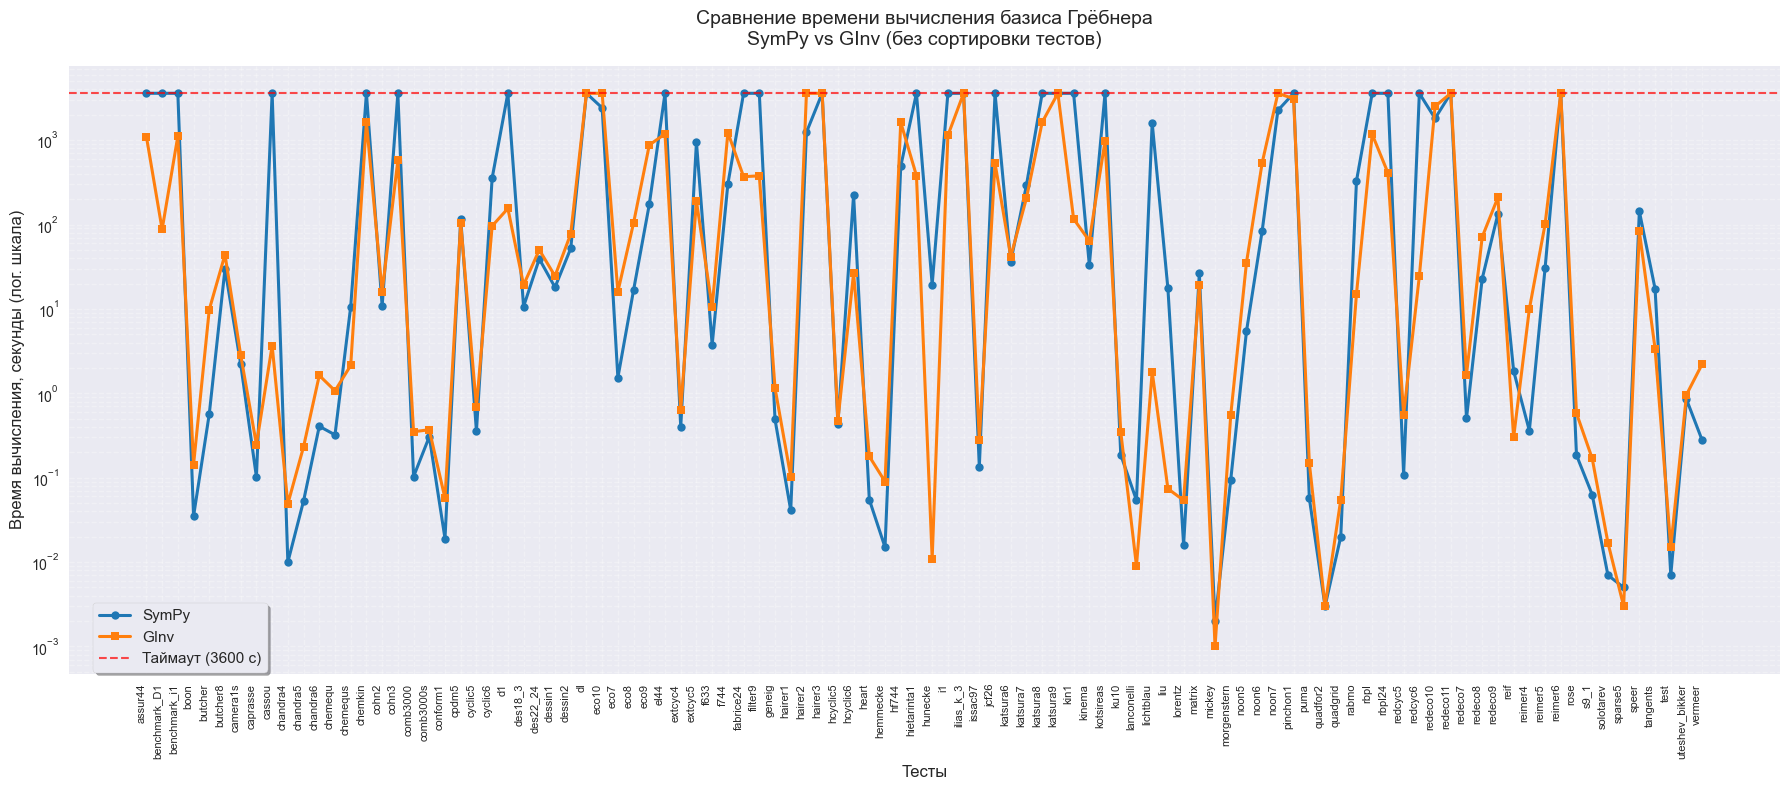

In [35]:
plt.figure(figsize=(18, 8))

pivot_time = df.pivot_table(
    index='test',
    columns='method',
    values='time',
    aggfunc='first'
).reset_index()

# Линия SymPy
plt.plot(pivot_time.index, pivot_time['sympy'], 
         marker='o', markersize=6, linewidth=2.2, 
         label='SymPy', color='#1f77b4')

# Линия GInv
plt.plot(pivot_time.index, pivot_time['ginv'], 
         marker='s', markersize=6, linewidth=2.2, 
         label='GInv', color='#ff7f0e')

# Линия таймаута
if df['timed_out'].any():
    timeout_value = df[df['timed_out']]['time'].max()
    plt.axhline(y=timeout_value, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
                label=f'Таймаут ({timeout_value:.0f} с)')

# Вертикальные подписи тестов
plt.xticks(ticks=pivot_time.index, 
           labels=pivot_time['test'], 
           rotation=90, 
           ha='right', 
           fontsize=8)

# Настройки осей и легенды
plt.yscale('log')  # логарифмическая шкала для наглядности
plt.ylabel('Время вычисления, секунды (лог. шкала)', fontsize=12)
plt.xlabel('Тесты', fontsize=12)
plt.title('Сравнение времени вычисления базиса Грёбнера\nSymPy vs GInv (без сортировки тестов)', fontsize=14, pad=15)

plt.grid(True, which="both", ls="--", alpha=0.3)

plt.legend(loc='lower left', fontsize=11, frameon=True, shadow=True, bbox_to_anchor=(0.01, -0.01))
plt.tight_layout()
plt.show()

In [36]:
# Таблица разницы (топ-10 самых больших расхождений)
pivot_time['diff_sec'] = pivot_time['ginv'] - pivot_time['sympy']
pivot_time['ratio'] = (pivot_time['ginv'] / pivot_time['sympy']).round(2)

print("\nТоп-10 тестов, где GInv медленнее SymPy (по разнице в секундах):")
print(pivot_time.sort_values('diff_sec', ascending=False).head(10)[
    ['test', 'sympy', 'ginv', 'diff_sec', 'ratio']
])

print("\nТоп-10 тестов, где GInv быстрее SymPy:")
print(pivot_time.sort_values('diff_sec').head(10)[
    ['test', 'sympy', 'ginv', 'diff_sec', 'ratio']
])


Топ-10 тестов, где GInv медленнее SymPy (по разнице в секундах):
method      test     sympy      ginv  diff_sec  ratio
42       hairer2  1241.520  3600.033  2358.513   2.90
72         noon7  2257.500  3600.039  1342.539   1.59
29         eco10  2417.651  3600.056  1182.405   1.49
48         hf744   491.954  1632.597  1140.643   3.32
37          f744   303.094  1233.889   930.795   4.07
82      redeco10  1812.610  2521.447   708.837   1.39
32          eco9   173.669   878.347   704.678   5.06
71         noon6    84.481   541.257   456.776   6.41
31          eco8    16.757   104.726    87.969   6.25
86       redeco9   133.611   209.727    76.116   1.57

Топ-10 тестов, где GInv быстрее SymPy:
method          test     sympy     ginv  diff_sec  ratio
8             cassou  3600.031    3.671 -3596.360   0.00
81           redcyc6  3600.026   24.425 -3575.601   0.01
1       benchmark_D1  3600.042   87.680 -3512.362   0.02
59              kin1  3600.032  116.818 -3483.214   0.03
23             

### Сравнение времени по всем тестам (с сортировкой по времени)

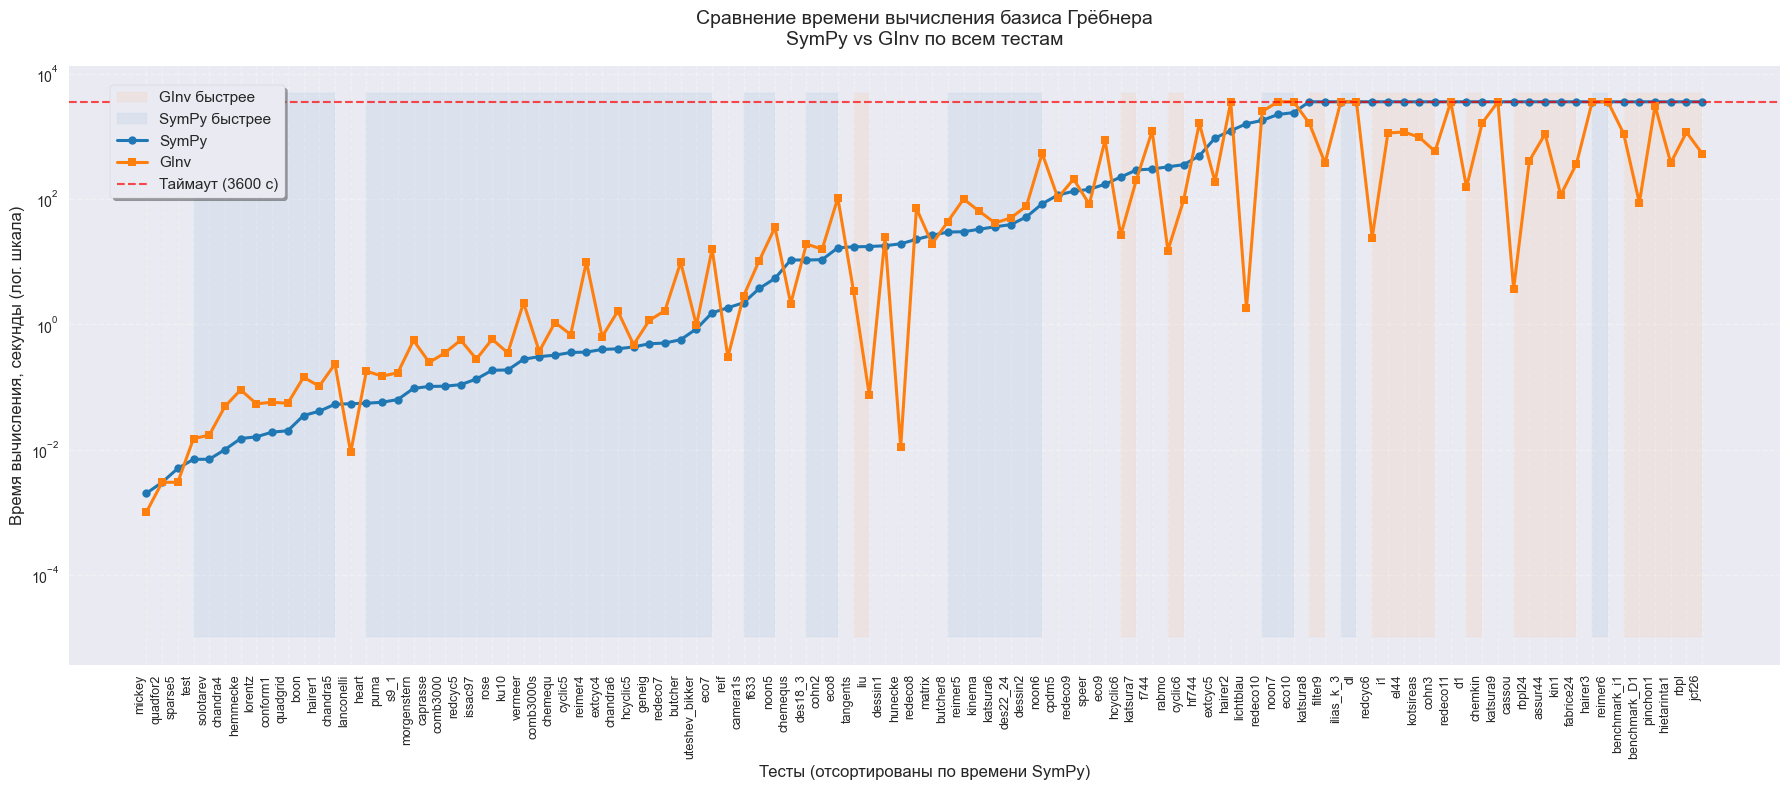

In [58]:
# Сортируем тесты по времени SymPy (от самого быстрого к медленному)
pivot_time = pivot_time.sort_values('sympy', ascending=True).reset_index(drop=True)

####

valid = pivot_time[['sympy', 'ginv']].notna().all(axis=1)
pivot_time['ginv_faster'] = False
pivot_time.loc[valid, 'ginv_faster'] = pivot_time.loc[valid, 'ginv'] < pivot_time.loc[valid, 'sympy']

plt.figure(figsize=(18, 8))

# Штриховка зон лидерства
plt.fill_between(
    pivot_time.index,
    1e-5, 5000,          
    where=pivot_time['ginv_faster'],
    color='#ff7f0e', alpha=0.07, zorder=1,
    label='GInv быстрее'
)

plt.fill_between(
    pivot_time.index,
    1e-5, 5000,
    where=(~pivot_time['ginv_faster']) & valid,
    color='#1f77b4', alpha=0.07, zorder=1,
    label='SymPy быстрее'
)

####

# Линия SymPy
plt.plot(pivot_time.index, pivot_time['sympy'], 
         marker='o', markersize=6, linewidth=2.2, 
         label='SymPy', color='#1f77b4')

# Линия GInv
plt.plot(pivot_time.index, pivot_time['ginv'], 
         marker='s', markersize=6, linewidth=2.2, 
         label='GInv', color='#ff7f0e')

# Линия таймаута
if df['timed_out'].any():
    timeout_value = df[df['timed_out']]['time'].max()  # берём максимальное значение таймаута
    plt.axhline(y=timeout_value, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
                label=f'Таймаут ({timeout_value:.0f} с)')

# Вертикальные подписи тестов
plt.xticks(ticks=pivot_time.index, 
           labels=pivot_time['test'], 
           rotation=90, 
           ha='right', 
           fontsize=9, 
           fontfamily='Arial')

# Настройки осей
plt.yscale('log')  # логарифмическая шкала
plt.ylabel('Время вычисления, секунды (лог. шкала)', fontsize=12)
plt.xlabel('Тесты (отсортированы по времени SymPy)', fontsize=12)
plt.title('Сравнение времени вычисления базиса Грёбнера\nSymPy vs GInv по всем тестам', 
          fontsize=14, pad=15)

plt.grid(True, which="both", ls="--", alpha=0.3)

# Легенда
plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True, bbox_to_anchor=(0.02, 0.98))
plt.tight_layout()
plt.show()

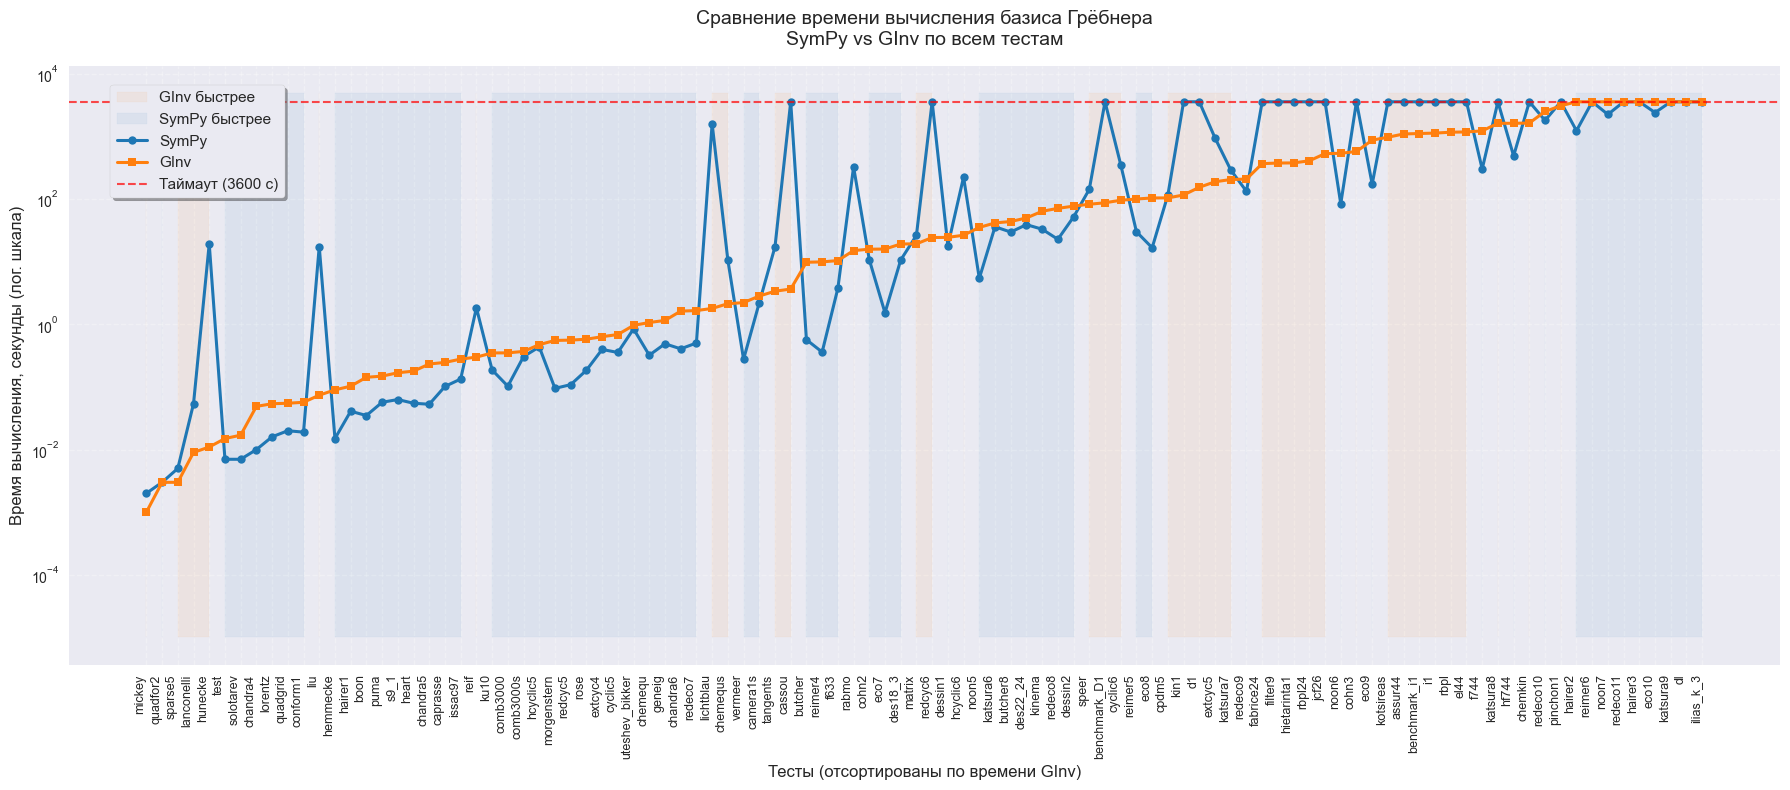

In [57]:
# Сортируем тесты по времени GInv (от самого быстрого к медленному)
pivot_time = pivot_time.sort_values('ginv', ascending=True).reset_index(drop=True)

####

# Определяем, где кто быстрее (только там, где оба значения не NaN)
valid = pivot_time[['sympy', 'ginv']].notna().all(axis=1)
pivot_time['ginv_faster'] = False
pivot_time.loc[valid, 'ginv_faster'] = pivot_time.loc[valid, 'ginv'] < pivot_time.loc[valid, 'sympy']

plt.figure(figsize=(18, 8))

# Штриховка зон лидерства
plt.fill_between(
    pivot_time.index,
    1e-5, 5000,
    where=pivot_time['ginv_faster'],
    color='#ff7f0e', alpha=0.07, zorder=1,
    label='GInv быстрее'
)

plt.fill_between(
    pivot_time.index,
    1e-5, 5000,
    where=(~pivot_time['ginv_faster']) & valid,
    color='#1f77b4', alpha=0.07, zorder=1,
    label='SymPy быстрее'
)

####

# Линия SymPy
plt.plot(pivot_time.index, pivot_time['sympy'], 
         marker='o', markersize=6, linewidth=2.2, 
         label='SymPy', color='#1f77b4')

# Линия GInv
plt.plot(pivot_time.index, pivot_time['ginv'], 
         marker='s', markersize=6, linewidth=2.2, 
         label='GInv', color='#ff7f0e')

# Линия таймаута
if df['timed_out'].any():
    timeout_value = df[df['timed_out']]['time'].max()  # берём максимальное значение таймаута
    plt.axhline(y=timeout_value, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
                label=f'Таймаут ({timeout_value:.0f} с)')

# Вертикальные подписи тестов
plt.xticks(ticks=pivot_time.index, 
           labels=pivot_time['test'], 
           rotation=90, 
           ha='right', 
           fontsize=9, 
           fontfamily='Arial')

# Настройки осей
plt.yscale('log')  # логарифмическая шкала
plt.ylabel('Время вычисления, секунды (лог. шкала)', fontsize=12)
plt.xlabel('Тесты (отсортированы по времени GInv)', fontsize=12)
plt.title('Сравнение времени вычисления базиса Грёбнера\nSymPy vs GInv по всем тестам', 
          fontsize=14, pad=15)

plt.grid(True, which="both", ls="--", alpha=0.3)

# Легенда
plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True, bbox_to_anchor=(0.02, 0.98))
plt.tight_layout()
plt.show()

### Корреляция времени с основными характеристиками входной системы 

Необходимо выявить закономерность: как характеристики системы уравнений влияют на время нахождения базиса Грёбнера? Для этого оценим корреляцию времени и метрик системы:

In [88]:
df[['time','num_vars','dimension','basis_size']].corr()

,time,num_vars,dimension,basis_size
time,1.000000,0.363356,0.363356,0.678107
num_vars,0.363356,1.000000,1.000000,0.310248
dimension,0.363356,1.000000,1.000000,0.310248
basis_size,0.678107,0.310248,0.310248,1.000000


Сильнее всего время коррелирует с размером базиса, но это не входной параметр. Возьмем за основу количество уравнений в самой системе.

### График отношения времени

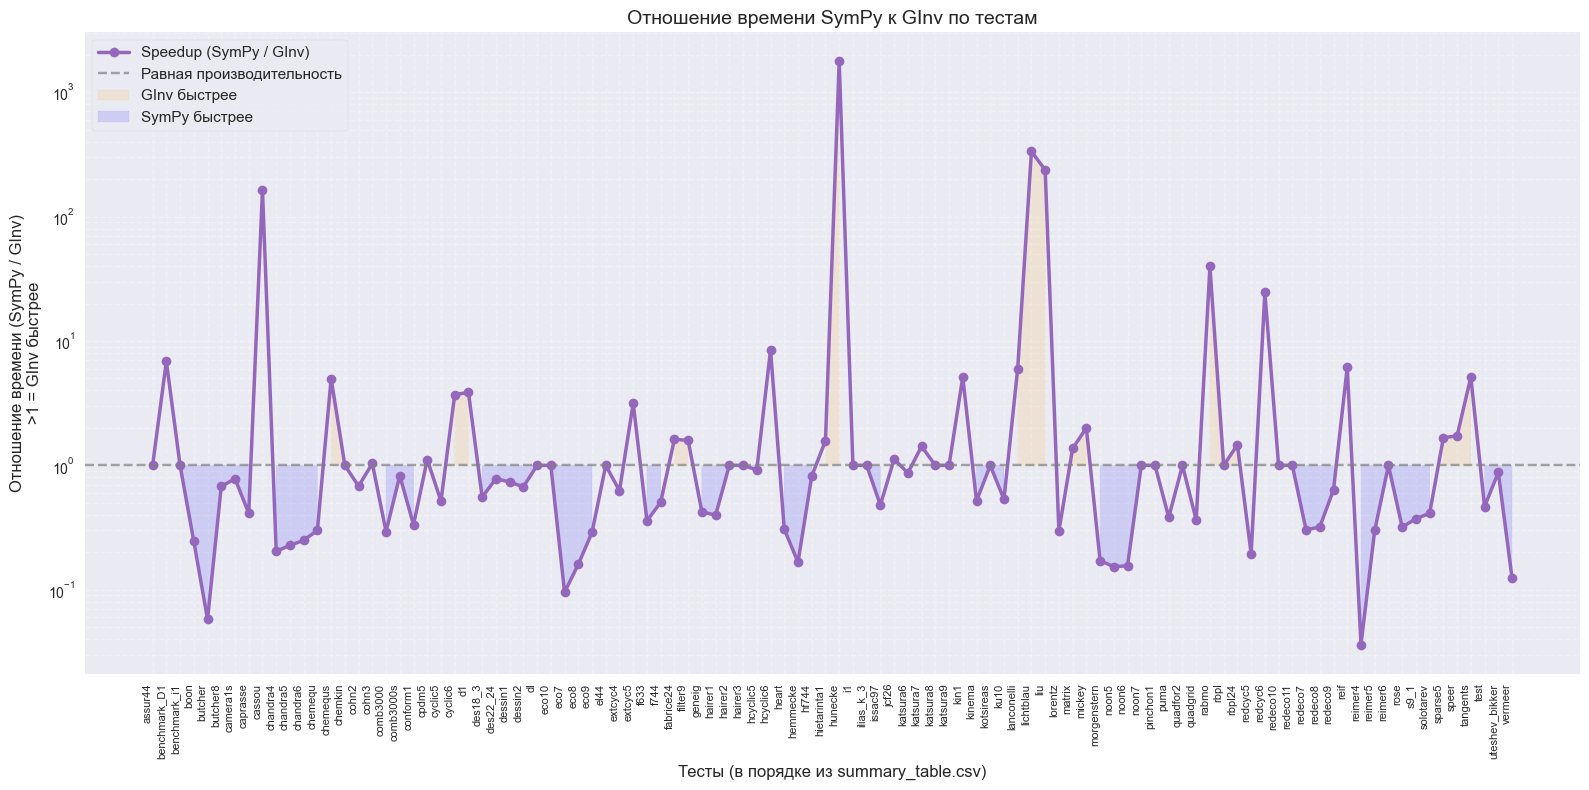

In [55]:
# Сводная таблица по тестам (в порядке из CSV)
pivot = df.pivot_table(index='test', columns='method', values='time').reset_index()

# Отношение времени: speedup > 1 => GInv быстрее
pivot['speedup'] = pivot['sympy'] / pivot['ginv']

# Добавляем число переменных для контекста
pivot = pivot.merge(df[['test', 'num_vars']].drop_duplicates(), on='test')

plt.figure(figsize=(16, 8))

plt.plot(pivot.index, pivot['speedup'], 
         marker='o', markersize=7, linewidth=2.5, 
         color='#9467bd', label='Speedup (SymPy / GInv)')

# Линия равенства
plt.axhline(y=1, color='gray', linestyle='--', alpha=0.7, label='Равная производительность')

# Заливка зон
plt.fill_between(pivot.index, 1, pivot['speedup'], 
                 where=(pivot['speedup'] > 1), color='orange', alpha=0.12, 
                 label='GInv быстрее')
plt.fill_between(pivot.index, 1, pivot['speedup'], 
                 where=(pivot['speedup'] < 1), color='blue', alpha=0.12, 
                 label='SymPy быстрее')

# Вертикальные подписи тестов
plt.xticks(ticks=pivot.index, 
           labels=pivot['test'], 
           rotation=90, 
           ha='right', 
           fontsize=8)

plt.yscale('log')
plt.ylabel('Отношение времени (SymPy / GInv)\n>1 = GInv быстрее', fontsize=12)
plt.xlabel('Тесты (в порядке из summary_table.csv)', fontsize=12)
plt.title('Отношение времени SymPy к GInv по тестам', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(loc='upper left', fontsize=11, frameon=True)

plt.tight_layout()
plt.show()

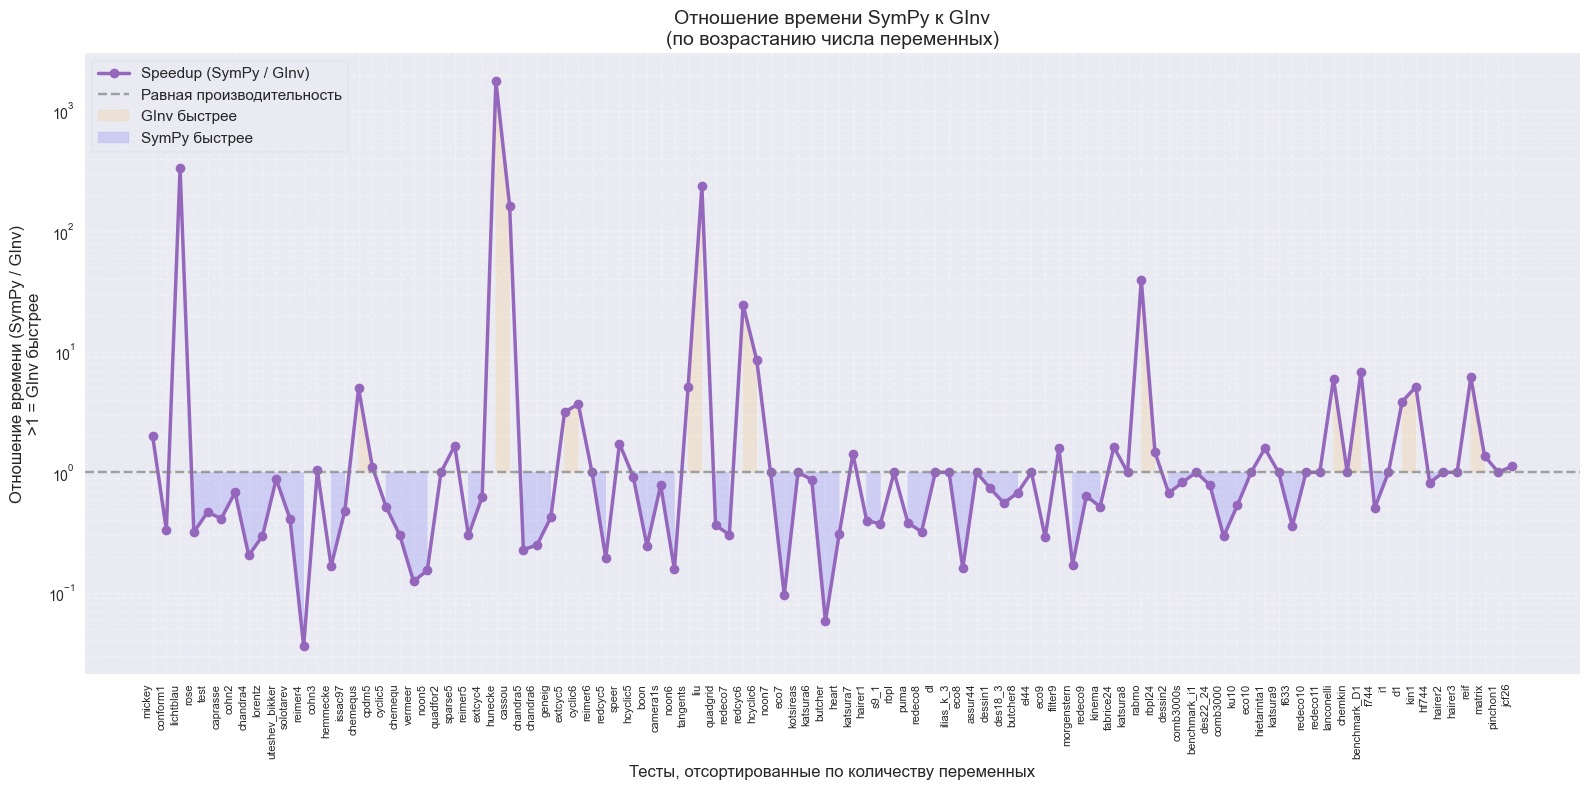

In [58]:
# Сортируем по числу переменных (возрастающий порядок)
pivot = pivot.sort_values('num_vars').reset_index(drop=True)

plt.figure(figsize=(16, 8))

plt.plot(pivot.index, pivot['speedup'],
         marker='o', markersize=7, linewidth=2.5,
         color='#9467bd', label='Speedup (SymPy / GInv)')

# Линия равенства
plt.axhline(y=1, color='gray', linestyle='--', alpha=0.7, label='Равная производительность')

# Заливка зон
plt.fill_between(pivot.index, 1, pivot['speedup'],
                 where=(pivot['speedup'] > 1), color='orange', alpha=0.12,
                 label='GInv быстрее')
plt.fill_between(pivot.index, 1, pivot['speedup'],
                 where=(pivot['speedup'] < 1), color='blue', alpha=0.12,
                 label='SymPy быстрее')

# Задаём метки в отсортированном порядке
plt.xticks(ticks=pivot.index,
           labels=pivot['test'],
           rotation=90,
           ha='right',
           fontsize=8)

plt.yscale('log')
plt.ylabel('Отношение времени (SymPy / GInv)\n>1 = GInv быстрее', fontsize=12)
plt.xlabel('Тесты, отсортированные по количеству переменных', fontsize=12)
plt.title('Отношение времени SymPy к GInv\n(по возрастанию числа переменных)', fontsize=14)

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(loc='upper left', fontsize=11, frameon=True)
plt.tight_layout()
plt.show()

На графике отношения времени (SymPy / GInv) видно, что в большинстве тестов классическое деление (SymPy) быстрее (точки ниже линии равенства). Однако в ряде случаев, особенно на системах с большим числом переменных, наблюдаются очень высокие значения speedup (до десятков и сотен раз), что говорит о значительном преимуществе инволютивного Janet-подобного деления (GInv) на сложных задачах.
Следует учитывать, что экстремально высокие значения speedup часто возникают из-за таймаута SymPy при лимите 3600 секунд, в то время как GInv успевает завершиться.

### Зависимость среднего и медианного времени от числа переменных (с учётом таймаутов)

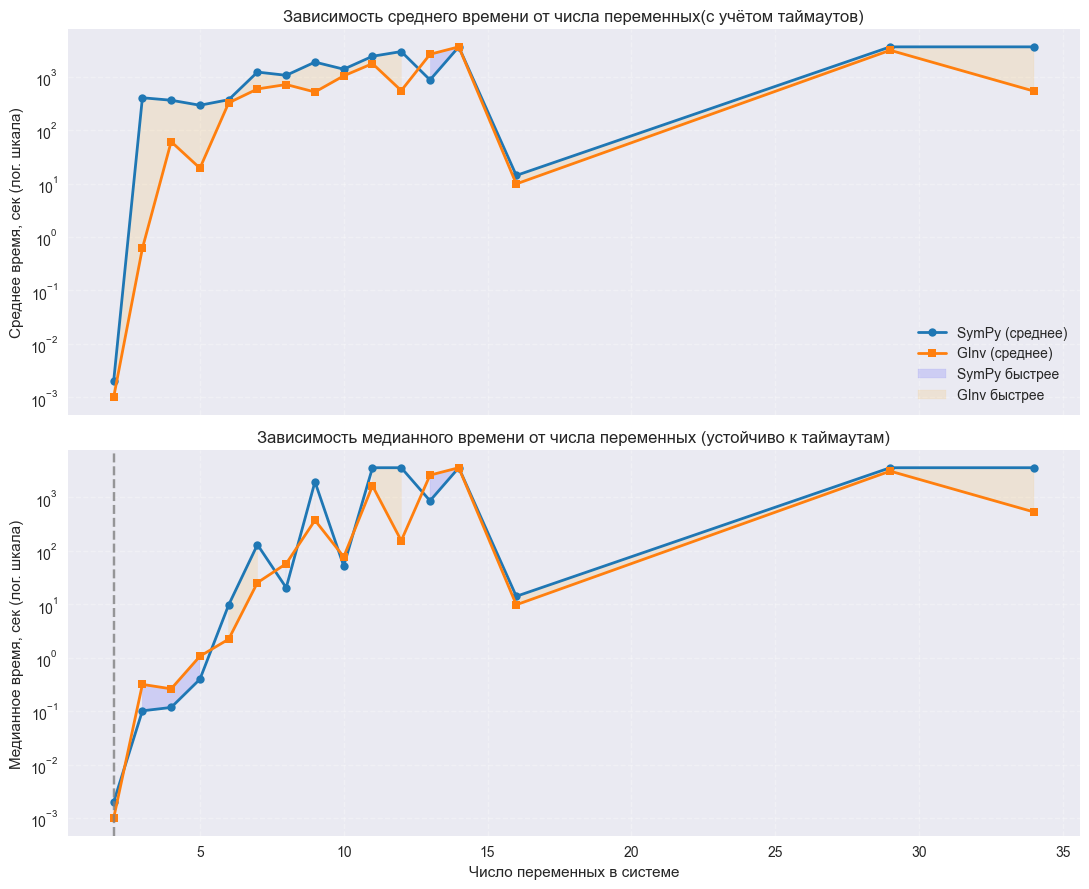

In [86]:
grouped = df.groupby(['num_vars', 'method'])['time'].agg(
    mean_time='mean',
    median_time='median',
    success_rate=lambda x: (x < 3600).mean() * 100   # % успешно завершённых
).reset_index()

# Разворачиваем для mean и median
pivot_mean = grouped.pivot(index='num_vars', columns='method', values='mean_time')
pivot_median = grouped.pivot(index='num_vars', columns='method', values='median_time')
pivot_success = grouped.pivot(index='num_vars', columns='method', values='success_rate')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

# Верхний график - среднее время
ax1.plot(pivot_mean.index, pivot_mean['sympy'], marker='o', markersize=6, linewidth=2,
         label='SymPy (среднее)', color='#1f77b4')
ax1.plot(pivot_mean.index, pivot_mean['ginv'], marker='s', markersize=6, linewidth=2,
         label='GInv (среднее)', color='#ff7f0e')

ax1.fill_between(pivot_mean.index, pivot_mean['sympy'], pivot_mean['ginv'],
                 where=(pivot_mean['sympy'] < pivot_mean['ginv']),
                 color='blue', alpha=0.12, label='SymPy быстрее')
ax1.fill_between(pivot_mean.index, pivot_mean['sympy'], pivot_mean['ginv'],
                 where=(pivot_mean['ginv'] < pivot_mean['sympy']),
                 color='orange', alpha=0.12, label='GInv быстрее')

ax1.set_yscale('log')
ax1.set_ylabel('Среднее время, сек (лог. шкала)', fontsize=11)
ax1.set_title('Зависимость среднего времени от числа переменных(с учётом таймаутов)', fontsize=12)
ax1.grid(True, ls='--', alpha=0.3)
ax1.legend(fontsize=10)

# Нижний график - медианное время
ax2.plot(pivot_median.index, pivot_median['sympy'], marker='o', markersize=6, linewidth=2,
         label='SymPy (медиана)', color='#1f77b4')
ax2.plot(pivot_median.index, pivot_median['ginv'], marker='s', markersize=6, linewidth=2,
         label='GInv (медиана)', color='#ff7f0e')

ax2.fill_between(pivot_median.index, pivot_median['sympy'], pivot_median['ginv'],
                 where=(pivot_median['sympy'] < pivot_median['ginv']),
                 color='blue', alpha=0.12)
ax2.fill_between(pivot_median.index, pivot_median['sympy'], pivot_median['ginv'],
                 where=(pivot_median['ginv'] < pivot_median['sympy']),
                 color='orange', alpha=0.12)

ax2.axvline(x=intersect_x, color='gray', linestyle='--', alpha=0.8)
ax2.set_yscale('log')
ax2.set_ylabel('Медианное время, сек (лог. шкала)', fontsize=11)
ax2.set_xlabel('Число переменных в системе', fontsize=11)
ax2.set_title('Зависимость медианного времени от числа переменных (устойчиво к таймаутам)', fontsize=12)
ax2.grid(True, ls='--', alpha=0.3)

plt.tight_layout()
plt.show()

Среднее время выполнения для GInv меньше на всех размерностях, что связано с большим числом таймаутов у SymPy. Среднее значение чувствительно к редким, но очень длительным вычислениям.

Медианное время отражает типичное поведение алгоритмов. На системах малой размерности SymPy демонстрирует более высокую скорость. Однако при увеличении числа переменных медианное время SymPy растёт быстрее, и после некоторой размерности преимущество переходит к GInv. Точка пересечения медианных кривых соответствует области, в которой методы имеют сопоставимую эффективность.

## Ключевая закономерность

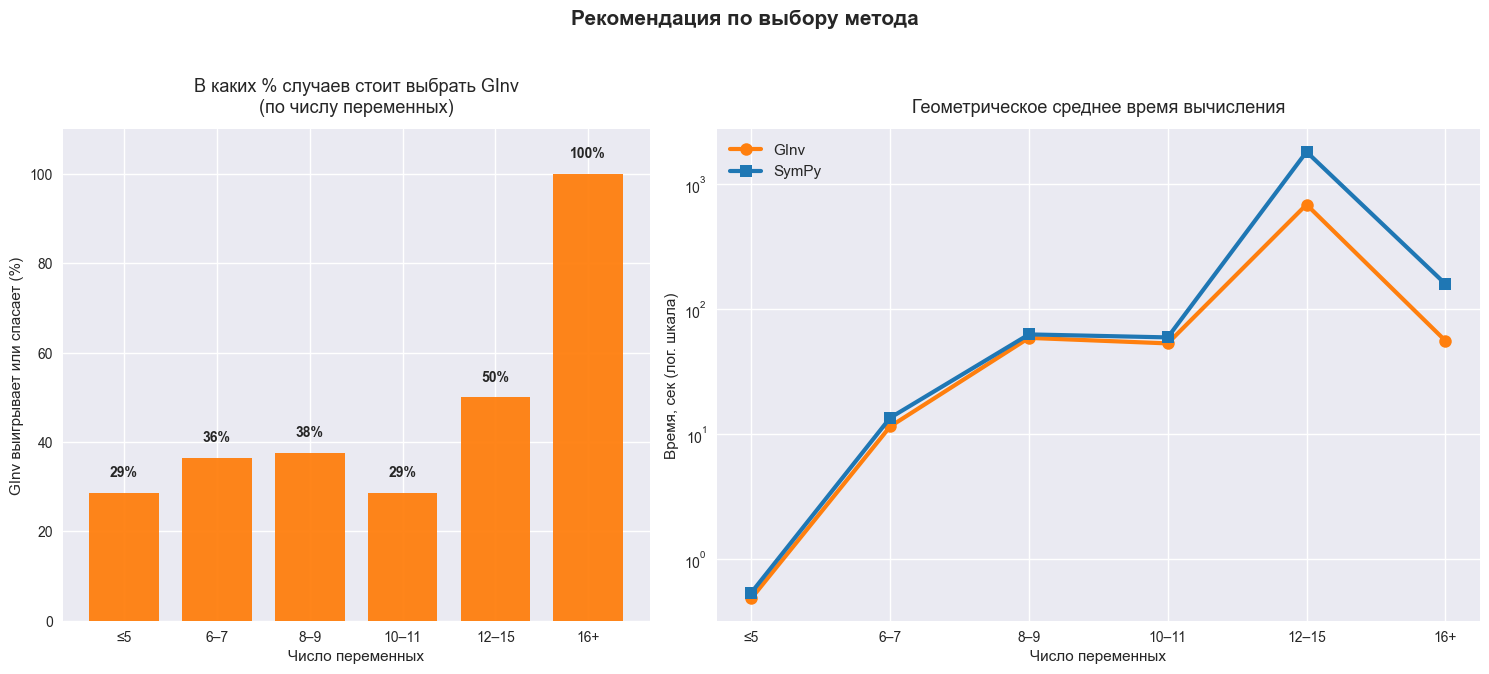

In [80]:
pivot_time = df.pivot_table(
    index='test',
    columns='method',
    values='time',
    aggfunc='first'
).reset_index()

pivot_time = pivot_time.rename(columns={'ginv': 'time_ginv', 'sympy': 'time_sympy'})

meta = df[df['method'] == 'sympy'][['test', 'num_vars', 'dimension', 'status']].copy()
meta = meta.rename(columns={'status': 'status_sympy'})

status_ginv = df[df['method'] == 'ginv'][['test', 'status']].rename(columns={'status': 'status_ginv'})
meta = meta.merge(status_ginv, on='test', how='outer')

# Объединяем
pivot = pivot_time.merge(meta, on='test', how='left')

# Распределение по числу переменных СУ
bins = [0, 5, 7, 9, 11, 15, 40]
labels = ['≤5', '6–7', '8–9', '10–11', '12–15', '16+']
pivot['num_vars_bin'] = pd.cut(pivot['num_vars'], bins=bins, labels=labels, include_lowest=True)

# Определяем победителя для каждого теста
def get_winner(row):
    if row['status_sympy'] == 'ok' and row['status_ginv'] == 'ok':
        if row['time_ginv'] < row['time_sympy']:
            return 'GInv быстрее'
        else:
            return 'SymPy быстрее'
    elif row['status_sympy'] != 'ok' and row['status_ginv'] == 'ok':
        return 'GInv спас (SymPy таймаут)'
    elif row['status_sympy'] == 'ok' and row['status_ginv'] != 'ok':
        return 'SymPy спас (GInv таймаут)'
    else:
        return 'Оба таймаут'

pivot['winner'] = pivot.apply(get_winner, axis=1)

# Статистика по числу переменных
stats = pivot.groupby('num_vars_bin', observed=True).agg(
    num_tests=('test', 'nunique'),
    ginv_success=('status_ginv', lambda x: (x == 'ok').sum()),
    sympy_success=('status_sympy', lambda x: (x == 'ok').sum()),
    ginv_faster=('winner', lambda x: (x == 'GInv быстрее').sum()),
    ginv_save=('winner', lambda x: (x == 'GInv спас (SymPy таймаут)').sum()),
    geo_time_ginv=('time_ginv', lambda x: np.exp(np.mean(np.log(x[x.notna()])))),
    geo_time_sympy=('time_sympy', lambda x: np.exp(np.mean(np.log(x[x.notna()]))))
).reset_index()

stats['ginv_win_rate'] = (stats['ginv_faster'] + stats['ginv_save']) / stats['num_tests'] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), gridspec_kw={'width_ratios': [1, 1.3]})

# Левый график - % случаев, где GInv лучше
bars = ax1.bar(stats['num_vars_bin'], stats['ginv_win_rate'], 
               color='#ff7f0e', alpha=0.95, width=0.75)
ax1.set_title('В каких % случаев стоит выбрать GInv\n(по числу переменных)', fontsize=13, pad=12)
ax1.set_ylabel('GInv выигрывает или спасает (%)', fontsize=11)
ax1.set_xlabel('Число переменных', fontsize=11)
ax1.set_ylim(0, 110)

for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 3, f'{h:.0f}%', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Правый график - рост геом. среднего времени
ax2.plot(stats['num_vars_bin'], stats['geo_time_ginv'], 
         marker='o', linewidth=3, markersize=9, color='#ff7f0e', label='GInv')
ax2.plot(stats['num_vars_bin'], stats['geo_time_sympy'], 
         marker='s', linewidth=3, markersize=9, color='#1f77b4', label='SymPy')
ax2.set_title('Геометрическое среднее время вычисления', fontsize=13, pad=12)
ax2.set_ylabel('Время, сек (лог. шкала)', fontsize=11)
ax2.set_xlabel('Число переменных', fontsize=11)
ax2.set_yscale('log')
ax2.legend(fontsize=11, loc='upper left')

# Общий заголовок
plt.suptitle('Рекомендация по выбору метода',
             fontsize=15, y=1.03, fontweight='bold')

plt.tight_layout()
plt.show()

Полученные графики объясняют выявленную закономерность: если в системе >10 переменных, то целесообразно для вычисления базиса Грёбнера будет использовать GInv. Применение инволютивного деления для систем нелинейных уравнений большой размерности позволяет добиться существенного выигрыша во времени при вычислении базиса Грёбнера. Для малых и средних систем выигрыш во времени, вероятнее всего, даст использование классического полиномиального деления, использующееся в улучшенном алгоритме Бухбергера в SymPy. С ростом числа переменных (особенно при 10 и более) наблюдается значительный рост геометрического среднего времени, а также наглядно видна его разница в обоих алгоритмах. На малых системах GInv находит базис Грёбнера немного медленнее, но отставание не настолько значительное, как в случае с отставанием SymPy на больших системах. 

Данные графики помогают заранее предположить, использование какого полиномиального деления быстрее приведет к нахождению базиса Грёбнера.